# SPA singlet vs triplet: AP1 and AP2 scans, no background fields

Does coherent state preparation transfer the **J = 0, F = 0** state (the nuclear-spin
*singlet*) as efficiently as the **J = 0, F = 1** sublevels (the *triplet*, mF = -1, 0, +1)?

After rotational cooling roughly 2/3 of the ground-state population sits in F = 0 and 1/3
is spread over F = 1. If the two transfer with different efficiency, the prepared fraction
depends on the RC outcome, so we need the two efficiencies to agree.

**Naming.** AP1 and AP2 are this repository's `SPA1` (J = 0 -> 1) and `SPA2` (J = 1 -> 2).
The passage is *spatial*, not chirped: each microwave sits at a fixed carrier and the DC
Stark shift sweeps the effective detuning through resonance as the molecule flies through
the beam.

**What is scanned.** Stage 1 scans AP1 alone in detuning and power. Stage 2 parks AP1 at
its optimum and scans AP2 in detuning and power, starting from J = 0 so the full physical
0 -> 1 -> 2 chain is simulated and AP1's imperfection propagates.

**No background fields.** No stray-microwave `background_field=True` field appears
anywhere. The DC Stark field is *not* a background to be removed: it is the adiabatic
sweep, and zeroing it removes the passage entirely. The nominal `Bz = 1e-3` is likewise
kept deliberately, so the mF sublevels are non-degenerate and adiabatic labelling is well
defined.

**Propagating all four sublevels at once is exact.** `Simulator` carries initial states as
an `(S, n)` block with no coupling between rows, so each evolves independently and the
weights can be applied afterwards. This is checked numerically at the end rather than
assumed.

In [1]:
%load_ext autoreload
%autoreload 2

import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

REPO_ROOT = Path.cwd().parents[2]
for extra in (REPO_ROOT / "src", REPO_ROOT / "benchmarks"):
    if str(extra) not in sys.path:
        sys.path.insert(0, str(extra))

import state_prep as sp
from state_prep import Simulator
from state_prep.utils import find_max_overlap_idx, select_eigenstate

from common import build_spa_cascade_setup

plt.rcParams.update({"font.size": 12, "figure.dpi": 110})

STATE_NAMES = ["singlet", "triplet_m", "triplet_0", "triplet_p"]
STATE_COLORS = ["#1b6ca8", "#d1495b", "#2e933c", "#e08a1e"]

## Setup

`build_spa_cascade_setup` (in `benchmarks/common.py`, alongside the SPA2 setup the
benchmarks and tests use) builds the trajectory, the measured DC Stark field, the nominal
magnetic field, the Hamiltonian and both microwave rungs. J = 0 and J = 3 stay in the
manifold because the electric field couples to them.

Microwave powers are anchored to a **Rabi rate** rather than set in Watts, so both rungs
are driven equivalently despite their different matrix elements. The anchor is the Rabi
rate the established SPA2 operating point of `power_w = 5e-5` produces.

In [2]:
setup = build_spa_cascade_setup()

mf01, mf12 = setup["microwave_fields"]        # ordered low rung first
hamiltonian = setup["hamiltonian"]
QN = hamiltonian.QN
trajectory = setup["trajectory"]
f01, f12 = setup["frequencies"]
r0_01, r0_12 = setup["positions"]

initial_states = setup["initial_states"]      # J=0: F=0 mF=0, then F=1 mF=-1,0,+1
targets_j1 = setup["targets_j1"]              # matched nuclear-spin partners in J=1
targets_j2 = setup["targets_j2"]              # ... and in J=2

J_OF_BASIS = np.array([q.J for q in QN])

print(f"AP1 (SPA1)  J=0 -> 1   f = {f01 / 1e9:.9f} GHz   beam centre z = {r0_01[2] * 100:.3f} cm")
print(f"AP2 (SPA2)  J=1 -> 2   f = {f12 / 1e9:.9f} GHz   beam centre z = {r0_12[2] * 100:.3f} cm")
print(f"nominal power: AP1 = {mf01.intensity.power:.4e} W   AP2 = {mf12.intensity.power:.4e} W")

omega1 = mf01.calculate_rabi_rate(initial_states[2], targets_j1[2], mf01.intensity.power, r0_01)
omega2 = mf12.calculate_rabi_rate(targets_j1[2], targets_j2[2], mf12.intensity.power, r0_12)
print(f"nominal Rabi rate: AP1 = {omega1 / 2 / np.pi / 1e3:.2f} kHz   "
      f"AP2 = {omega2 / 2 / np.pi / 1e3:.2f} kHz   (matched: {np.isclose(omega1, omega2)})")
print(f"Hilbert space: n = {len(QN)}   forward velocity = {trajectory.Vini[2]:.0f} m/s")

AP1 (SPA1)  J=0 -> 1   f = 13.340050145 GHz   beam centre z = 0.000 cm
AP2 (SPA2)  J=1 -> 2   f = 26.668808191 GHz   beam centre z = 2.857 cm
nominal power: AP1 = 4.0000e-05 W   AP2 = 5.0000e-05 W
nominal Rabi rate: AP1 = 39.45 kHz   AP2 = 39.45 kHz   (matched: True)
Hilbert space: n = 64   forward velocity = 184 m/s


The singlet/triplet naming is a nuclear-spin label. Tying it to explicit F, mF confirms
the singlet really is F = 0 and the triplets are the three F = 1 sublevels:

In [3]:
def coupled_label(state):
    return state.transform_to_coupled().largest.state_string_custom(["F1", "F", "mF"])

print(f"{'':11}{'J = 0 (initial)':<28}{'J = 1 (AP1 target)':<28}{'J = 2 (AP2 target)'}")
for name, s0, s1, s2 in zip(STATE_NAMES, initial_states, targets_j1, targets_j2):
    print(f"{name:11}{coupled_label(s0):<28}{coupled_label(s1):<28}{coupled_label(s2)}")

           J = 0 (initial)             J = 1 (AP1 target)          J = 2 (AP2 target)
singlet    |F1 = 1/2, F = 0, mF = 0>   |F1 = 3/2, F = 1, mF = 0>   |F1 = 5/2, F = 2, mF = 0>
triplet_m  |F1 = 1/2, F = 1, mF = -1>  |F1 = 3/2, F = 2, mF = -1>  |F1 = 5/2, F = 3, mF = -1>
triplet_0  |F1 = 1/2, F = 1, mF = 0>   |F1 = 3/2, F = 2, mF = 0>   |F1 = 5/2, F = 3, mF = 0>
triplet_p  |F1 = 1/2, F = 1, mF = 1>   |F1 = 3/2, F = 2, mF = 1>   |F1 = 5/2, F = 3, mF = 1>


## Observables

**The reported transfer is the matched partner, one specific state per chain.** The nuclear
spin label is carried through unchanged, so the singlet chain is

    J=0 |F=0, mF=0>  ->  J=1 |F=1, mF=0>  ->  J=2 |F=2, mF=0>

and each triplet chain keeps its own mF, e.g. triplet_p is

    J=0 |F=1, mF=+1>  ->  J=1 |F=2, mF=+1>  ->  J=2 |F=3, mF=+1>

**Targets are identified by their quantum numbers at readout, not by a tracked index.**
`probabilities_final[..., k]` is the population in `V_fin[:, k]`, the *final-time*
eigenbasis, so that is the basis the states must be identified in. Resolving a target to
an eigenstate at t = 0 and then indexing the final array assumes the adiabatic label
survived the whole trajectory, and it does not always: where two levels cross, the
population follows its diabatic branch while the label follows the other. In this system
that is not rare -- the Stark ramp-down folds the hyperfine structure together and most
labels cross something. `IMPROVEMENTS.md` has the measurements, and the same crossing is
analysed from the Stark-sweep side in `j2_mf0_crossing_report.md` in the `centrex_tlf`
repository.

Which (J, F1, F, mF) each target *becomes* is itself physics: at t = 0 the Stark field
mixes F badly, and F only becomes good once the field has ramped off. So the identities are
measured, by propagating the DC fields with the microwaves switched off, rather than
assumed from the naming. F1 is part of the label because (J, F, mF) is not unique -- J = 1
has two F = 1 levels.

Two further numbers are computed, but **only as cross-checks on that one**, never as the
reported efficiency:

- **Tracked index** -- the same population read the old way, through the t = 0 index.
  Comparing it against the matched partner is a real label-swap detector: if they differ,
  the tracked reading is the one to distrust. (The previous version of this notebook
  compared against a sum over near-degenerate neighbours instead, which cannot detect a
  swap -- for the singlet and triplet_0 that group is the single state itself, so the
  difference was identically zero and always reported "no swaps".)
- **Manifold sum** -- everything in the target's rotational manifold. Used only to say where
  the missing population went: the gap to the matched partner is population that reached the
  right J but a different hyperfine substate.

`V_ini` is the eigenbasis of the slow Hamiltonian at t = 0, and is still checked against a
direct `eigh` so the two conventions cannot drift apart. Energies are angular frequencies.

In [4]:
H_tini = hamiltonian.get_H_t_func()(0.0)
_e_ini, V_CHECK = np.linalg.eigh(H_tini)
V_CHECK = V_CHECK[:, np.argsort(_e_ini)]

IDENTITY_CACHE = {}
IDENTITY_N_STEPS = 10_000   # identities are stable well below this; checked across 2k-40k

# Tolerance for matching quantum numbers between the reference run and a scan run.
# J, F and mF are good to ~1e-4 at readout, but F1 is not: the singlets come out at
# F1 = 1.4922 +- 0.0883 (J = 1) and 2.4966 +- 0.0579 (J = 2), because F1 stays somewhat
# mixed. F1 is nonetheless needed, since (J, F, mF) alone is degenerate -- J = 1 has two
# F = 1 levels. The competing level sits a full 1.0 away in F1, so a tolerance far above
# the run-to-run drift and far below that separation is both safe and unambiguous.
IDENTITY_TOL = 0.05


def manifold_of_eigenstates(V):
    """Rotational manifold each t=0 eigenvector predominantly belongs to."""
    weight = np.abs(V) ** 2
    js = np.unique(J_OF_BASIS)
    per_j = np.array([weight[J_OF_BASIS == j].sum(axis=0) for j in js])
    return js[per_j.argmax(axis=0)]


def manifold_indices(V, j):
    return np.flatnonzero(manifold_of_eigenstates(V) == j)


def readout_identities(targets, j_target):
    """(J, F1, F, mF) each target has become once the Stark field has ramped off.

    Measured, not assumed. At t = 0 the Stark field mixes F badly, so a target's F
    is only a good quantum number at readout, and which value it ends up with is
    physics rather than bookkeeping. Propagating the DC fields with the microwaves
    off answers it directly, in one run for all four targets.
    """
    if j_target in IDENTITY_CACHE:
        return IDENTITY_CACHE[j_target]

    sim = Simulator(
        setup["trajectory"], setup["electric_field"], setup["magnetic_field"],
        list(targets), hamiltonian, None,
    )
    ref = sim.run(
        N_steps=IDENTITY_N_STEPS, store_probabilities=False,
        store_final_probabilities=True, progress=False,
    )
    table = ref.final_quantum_numbers()
    identities = []
    for s in range(len(targets)):
        idx = int(np.argmax(ref.probabilities_final[s]))
        identities.append({k: float(table[k][idx]) for k in ("J", "F1", "F", "mF")})
    IDENTITY_CACHE[j_target] = identities
    return identities


def transfer_observables(result, targets, j_target):
    """(matched, tracked, manifold) final populations, each shaped (B, n_initial).

    `matched` is the reported number: the population of the eigenstate carrying the
    target's quantum numbers at readout. `probabilities_final[..., k]` is the
    population in `V_fin[:, k]`, so the states are identified in the basis the
    populations are actually expressed in.

    `tracked` is the same population read the old way, through an index taken at
    t = 0 with `find_max_overlap_idx`. It is kept only so the diagnostics cell can
    compare the two: that comparison is a genuine label-swap detector, whereas
    comparing against a sum over near-degenerate neighbours is not.
    """
    probs = result.probabilities_final
    V = result.V_ini
    assert np.allclose(np.abs(V), np.abs(V_CHECK), atol=1e-8), "V_ini is not eigh(H_slow(0))"

    table = result.final_quantum_numbers()
    manifold = manifold_indices(V, j_target)
    identities = readout_identities(targets, j_target)

    matched, tracked = [], []
    for s, (target, identity) in enumerate(zip(targets, identities)):
        matched.append(probs[:, s, select_eigenstate(table, identity, tolerance=IDENTITY_TOL)])
        tracked.append(probs[:, s, find_max_overlap_idx(target.state_vector(QN), V)])
    return (
        np.stack(matched, axis=-1),
        np.stack(tracked, axis=-1),
        probs[:, :, manifold].sum(axis=-1),
    )


def check_normalisation(result, label):
    err = np.abs(result.probabilities_final.sum(axis=-1) - 1.0).max()
    print(f"{label}: max |sum(P) - 1| = {err:.2e}")
    assert err < 1e-9, "populations are not normalised"
    return err

## Parallelism

Everything here runs on the CPU batched shared-slow path,
`Simulator.run_microwave_scan`. `workers=8` splits the batch into chunks across processes;
output is bitwise identical to serial. `blas_threads` is left at its default of 1 on
purpose -- the matrices are n = 64, so OpenBLAS's internal threading is overhead, and
unpinning it would oversubscribe the cores against the workers.

In [5]:
WORKERS = 8
N_STEPS = 10_000
N_STEPS_RECON = 2_000

## Stage 1 -- AP1 alone (J = 0 -> 1)

Only `mf01` is on the simulator, so nothing addresses J = 2.

A coarse reconnaissance scan first, both to locate the feature and to measure the
per-point cost on this machine before committing to the fine grid.

In [6]:
sim_ap1 = Simulator(
    setup["trajectory"], setup["electric_field"], setup["magnetic_field"],
    initial_states, hamiltonian, [mf01],
)

recon_det = np.linspace(-10e6, 10e6, 41)
det_r, pref_r = sp.scan_grid(n_fields=1, detunings_hz=recon_det)

t0 = time.perf_counter()
recon = sim_ap1.run_microwave_scan(
    detunings_hz=det_r, intensity_prefactors=pref_r, N_steps=N_STEPS_RECON,
    store_final_probabilities=True, progress=False, workers=WORKERS,
)
dt = time.perf_counter() - t0
per_pt = dt / det_r.shape[0]
print(f"reconnaissance: {det_r.shape[0]} points, N_steps={N_STEPS_RECON}, "
      f"workers={WORKERS} -> {dt:.1f} s ({per_pt * 1e3:.0f} ms/point)")
print(f"implied cost at N_steps={N_STEPS}: {per_pt * N_STEPS / N_STEPS_RECON:.2f} s/point")

_, _, recon_p = transfer_observables(recon, targets_j1, j_target=1)
above = recon_det[recon_p.max(axis=-1) > 0.01]
print(f"AP1 feature spans {above.min() / 1e6:+.1f} to {above.max() / 1e6:+.1f} MHz")

reconnaissance: 41 points, N_steps=2000, workers=8 -> 6.1 s (150 ms/point)
implied cost at N_steps=10000: 0.75 s/point


AP1 feature spans -3.5 to +6.5 MHz


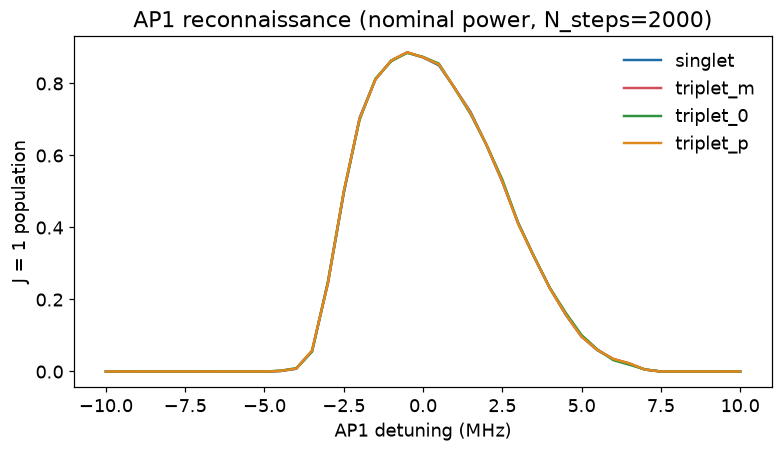

In [7]:
fig, ax = plt.subplots(figsize=(7, 4), constrained_layout=True)
for s, (name, color) in enumerate(zip(STATE_NAMES, STATE_COLORS)):
    ax.plot(recon_det / 1e6, recon_p[:, s], color=color, label=name, lw=1.6)
ax.set_xlabel("AP1 detuning (MHz)")
ax.set_ylabel("J = 1 population")
ax.set_title(f"AP1 reconnaissance (nominal power, N_steps={N_STEPS_RECON})")
ax.legend(frameon=False)
plt.show()

### Stage 1 fine grid

Detuning bounds bracket the feature found above. The power axis is an **intensity**
prefactor, so couplings scale as its square root -- a prefactor of 4 doubles the Rabi rate.
It is capped at about 32 because beyond that the Rabi oscillation becomes fast enough that
`N_steps` starts to under-resolve it; the convergence check below tests the top of the range.

`scan_grid` takes the outer product with the **detuning axis varying slowest**, so results
reshape as `(n_detunings, n_prefactors, ...)`.

In [8]:
det1_axis = np.linspace(-6e6, 8e6, 41)
pref_axis = np.logspace(-2, 1.5, 13)

det1, pref1 = sp.scan_grid(
    n_fields=1, detunings_hz=det1_axis, intensity_prefactors=pref_axis,
)
print(f"stage 1: {det1.shape[0]} scan points "
      f"({det1_axis.size} detunings x {pref_axis.size} prefactors)")

t0 = time.perf_counter()
res1 = sim_ap1.run_microwave_scan(
    detunings_hz=det1, intensity_prefactors=pref1, N_steps=N_STEPS,
    store_final_probabilities=True, progress=True, workers=WORKERS,
)
print(f"elapsed: {time.perf_counter() - t0:.1f} s")
check_normalisation(res1, "stage 1")

stage 1: 533 scan points (41 detunings x 13 prefactors)


elapsed: 226.7 s
stage 1: max |sum(P) - 1| = 3.08e-12


np.float64(3.083755473198835e-12)

In [9]:
shape1 = (det1_axis.size, pref_axis.size, len(initial_states))
ap1_matched, ap1_tracked, ap1_manifold = (
    a.reshape(shape1) for a in transfer_observables(res1, targets_j1, j_target=1)
)
print("transfer arrays:", ap1_manifold.shape, "= (detuning, prefactor, initial state)")


def print_identities(targets, j_target):
    """What each target has become at readout, measured with the microwaves off."""
    print(f"J = {j_target} readout identities:")
    for name, i in zip(STATE_NAMES, readout_identities(targets, j_target)):
        print(f"  {name:11} J = {i['J']:.3f}   F1 = {i['F1']:.3f}   "
              f"F = {i['F']:.3f}   mF = {i['mF']:+.3f}")


print_identities(targets_j1, 1)

transfer arrays: (41, 13, 4) = (detuning, prefactor, initial state)
J = 1 readout identities:
  singlet     J = 1.000   F1 = 1.492   F = 1.000   mF = -0.000
  triplet_m   J = 1.000   F1 = 1.500   F = 2.000   mF = -1.000
  triplet_0   J = 1.000   F1 = 1.500   F = 2.000   mF = -0.000
  triplet_p   J = 1.000   F1 = 1.500   F = 2.000   mF = +1.000


### Stage 1 optimum

The optimum is the joint argmax over the grid of the **minimum across the four sublevels** --
the point where *all four* transfer well, which is the criterion the question actually asks
about. Each sublevel's individual argmax is reported too, since whether they coincide is
itself part of the answer.

In [10]:
def report_optimum(transfer, manifold, det_axis, pref_axis, label, threshold=0.999):
    worst = transfer.min(axis=-1)
    di, pi = np.unravel_index(worst.argmax(), worst.shape)
    print(f"{label} optimum (maximin over sublevels):")
    print(f"  detuning  = {det_axis[di] / 1e6:+.3f} MHz")
    print(f"  prefactor = {pref_axis[pi]:.3f}  (Rabi x {np.sqrt(pref_axis[pi]):.2f})")
    print(f"  worst sublevel = {worst[di, pi]:.6f}")
    print("  per sublevel at this point, and each one's own best point:")
    for s, name in enumerate(STATE_NAMES):
        sdi, spi = np.unravel_index(transfer[:, :, s].argmax(), transfer.shape[:2])
        print(f"    {name:11} {transfer[di, pi, s]:.6f}   best {transfer[sdi, spi, s]:.6f} "
              f"at {det_axis[sdi] / 1e6:+.3f} MHz, prefactor {pref_axis[spi]:.3f}")
    print(f"  spread across sublevels at the optimum: "
          f"{transfer[di, pi].max() - transfer[di, pi].min():.2e}")
    print(f"  reached J but the wrong hyperfine substate: "
          f"{np.abs(manifold[di, pi] - transfer[di, pi]).max():.2e}")

    # A single argmax is close to arbitrary when many points saturate, so report the
    # region where every sublevel clears the threshold. That is the useful thing
    # experimentally: how much room there is around the setpoint.
    ok = worst > threshold
    if ok.any():
        d_ok, p_ok = det_axis[ok.any(axis=1)], pref_axis[ok.any(axis=0)]
        print(f"  all four sublevels > {threshold} over "
              f"{d_ok.min() / 1e6:+.3f} to {d_ok.max() / 1e6:+.3f} MHz and "
              f"prefactor {p_ok.min():.3f} to {p_ok.max():.3f} "
              f"({ok.sum()} of {ok.size} grid points)")
    else:
        print(f"  no grid point has all four sublevels above {threshold}")
    return di, pi


di1, pi1 = report_optimum(ap1_matched, ap1_manifold, det1_axis, pref_axis, "AP1")
D1_OPT, PREF1_OPT = det1_axis[di1], pref_axis[pi1]

AP1 optimum (maximin over sublevels):
  detuning  = +1.350 MHz
  prefactor = 16.156  (Rabi x 4.02)
  worst sublevel = 0.999894
  per sublevel at this point, and each one's own best point:
    singlet     0.999983   best 0.999999 at +0.300 MHz, prefactor 16.156
    triplet_m   0.999894   best 0.999895 at +1.350 MHz, prefactor 31.623
    triplet_0   0.999997   best 0.999999 at +0.300 MHz, prefactor 8.254
    triplet_p   0.999894   best 0.999894 at +1.350 MHz, prefactor 16.156
  spread across sublevels at the optimum: 1.02e-04
  reached J but the wrong hyperfine substate: 1.03e-04
  all four sublevels > 0.999 over -1.100 to +3.800 MHz and prefactor 4.217 to 31.623 (41 of 533 grid points)


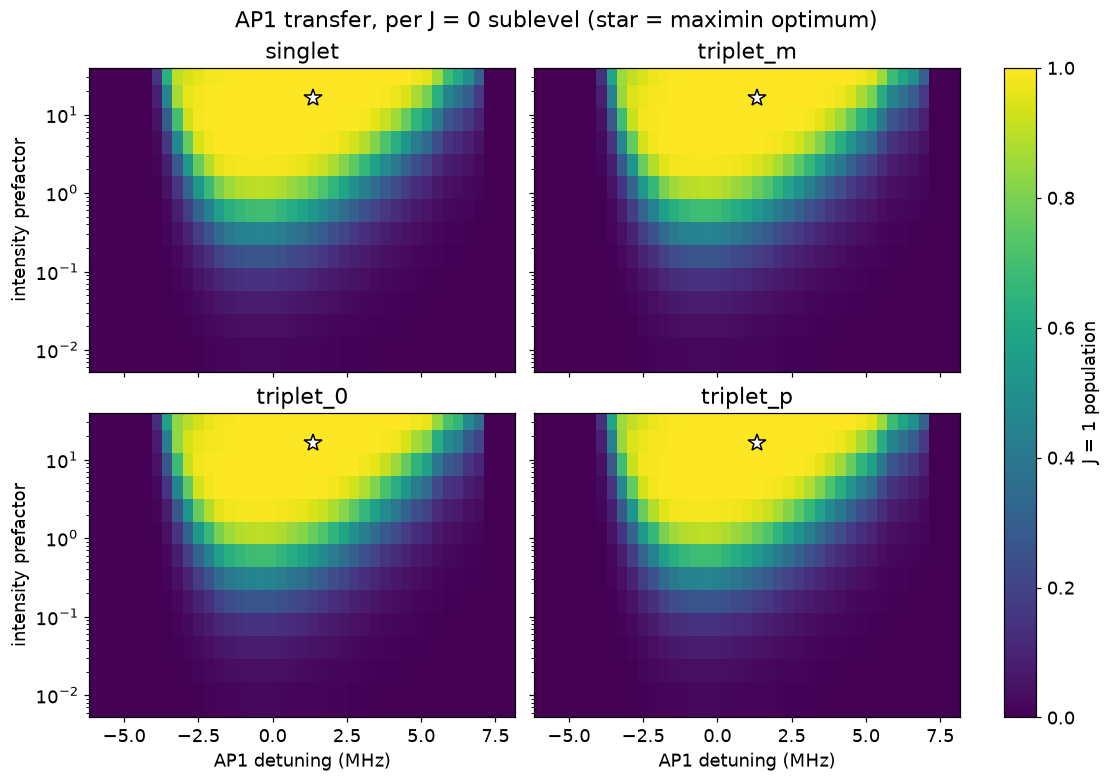

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharex=True, sharey=True,
                         constrained_layout=True)
for s, (name, ax) in enumerate(zip(STATE_NAMES, axes.ravel())):
    im = ax.pcolormesh(det1_axis / 1e6, pref_axis, ap1_matched[:, :, s].T,
                       vmin=0, vmax=1, shading="nearest", cmap="viridis")
    ax.set_yscale("log")
    ax.set_title(name)
    ax.plot(D1_OPT / 1e6, PREF1_OPT, "w*", ms=12, mec="k")
for ax in axes[-1]:
    ax.set_xlabel("AP1 detuning (MHz)")
for ax in axes[:, 0]:
    ax.set_ylabel("intensity prefactor")
fig.colorbar(im, ax=axes, label="J = 1 population")
fig.suptitle("AP1 transfer, per J = 0 sublevel (star = maximin optimum)")
plt.show()

### The comparison

The two panels below are the deliverable for AP1: four curves that lie on top of each
other. The lower panel shows the spread (max - min across the four sublevels) on a log
scale, which is the quantitative version of the same statement.

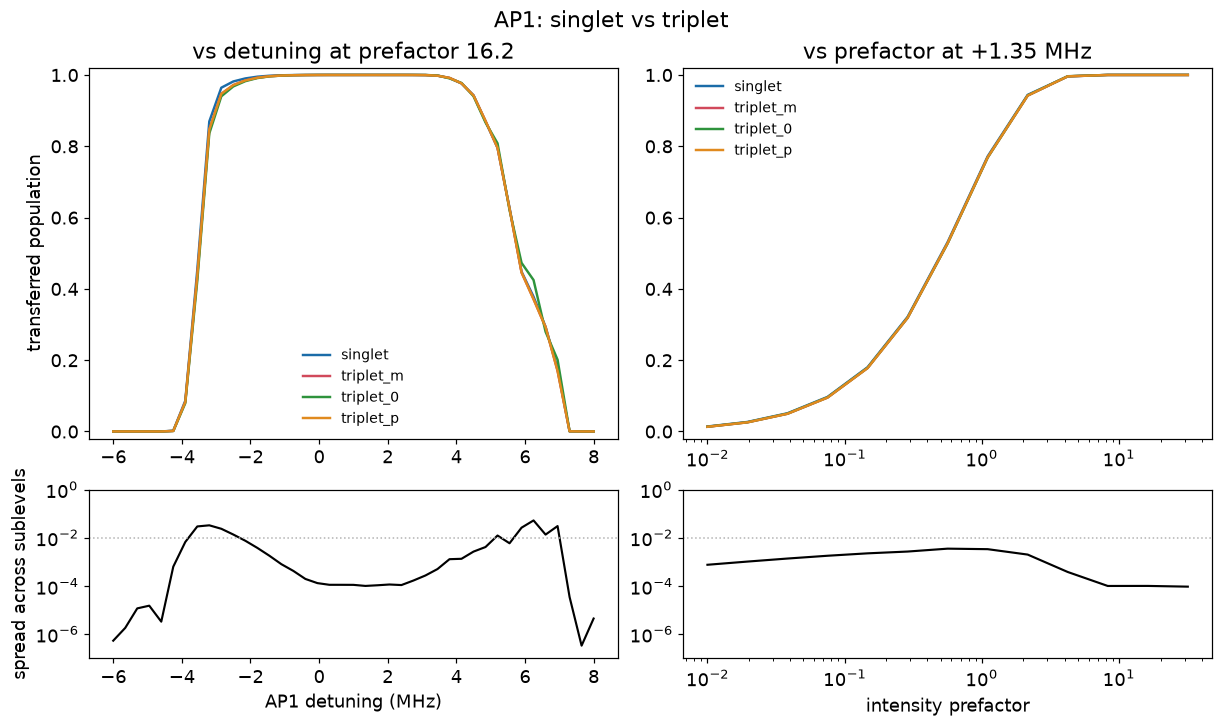

In [12]:
def comparison_figure(transfer, det_axis, pref_axis, di, pi, xlabel, title):
    fig, axes = plt.subplots(2, 2, figsize=(11, 6.5), constrained_layout=True,
                             gridspec_kw={"height_ratios": [2.2, 1]})

    for s, (name, color) in enumerate(zip(STATE_NAMES, STATE_COLORS)):
        axes[0, 0].plot(det_axis / 1e6, transfer[:, pi, s], color=color, label=name, lw=1.6)
        axes[0, 1].plot(pref_axis, transfer[di, :, s], color=color, label=name, lw=1.6)

    spread_det = transfer[:, pi].max(axis=-1) - transfer[:, pi].min(axis=-1)
    spread_pref = transfer[di].max(axis=-1) - transfer[di].min(axis=-1)
    axes[1, 0].semilogy(det_axis / 1e6, np.maximum(spread_det, 1e-12), "k-", lw=1.4)
    axes[1, 1].loglog(pref_axis, np.maximum(spread_pref, 1e-12), "k-", lw=1.4)

    axes[0, 0].set_title(f"vs detuning at prefactor {pref_axis[pi]:.3g}")
    axes[0, 1].set_title(f"vs prefactor at {det_axis[di] / 1e6:+.3g} MHz")
    axes[0, 0].set_ylabel("transferred population")
    axes[1, 0].set_ylabel("spread across sublevels")
    axes[1, 0].set_xlabel(xlabel)
    axes[1, 1].set_xlabel("intensity prefactor")
    axes[0, 1].set_xscale("log")
    for ax in axes[0]:
        ax.set_ylim(-0.02, 1.02)
        ax.legend(frameon=False, fontsize=9)
    for ax in axes[1]:
        ax.axhline(1e-2, color="0.7", ls=":", lw=1)
        ax.set_ylim(1e-7, 1)
    fig.suptitle(title)
    plt.show()


comparison_figure(ap1_matched, det1_axis, pref_axis, di1, pi1,
                  "AP1 detuning (MHz)", "AP1: singlet vs triplet")

## Stage 2 -- AP1 parked at its optimum, AP2 scanned (J = 1 -> 2)

Both rungs are now on the simulator, ordered **low rung first**, which
`build_rotating_frame_shift` requires for a cascade. The initial states are still the four
**J = 0** sublevels, so the full 0 -> 1 -> 2 chain is simulated and AP1's imperfection
propagates into the AP2 result.

AP1's fixed detuning is passed as a constant column of `detunings_hz`. In a cascade J = 2
sits on top of both rungs and must carry both detunings; `build_rotating_frame_shift`
accumulates them up the ladder, matching what `Simulator.run` has always done.

In [13]:
sim_ap2 = Simulator(
    setup["trajectory"], setup["electric_field"], setup["magnetic_field"],
    initial_states, hamiltonian, [mf01, mf12],
)

recon2_det = np.linspace(-6e6, 6e6, 49)
det_r2, pref_r2 = sp.scan_grid(
    n_fields=2, detunings_hz=recon2_det, detuning_fields=[1], prefactor_fields=[1],
)
det_r2[:, 0] = D1_OPT
pref_r2[:, 0] = PREF1_OPT

recon2 = sim_ap2.run_microwave_scan(
    detunings_hz=det_r2, intensity_prefactors=pref_r2, N_steps=N_STEPS_RECON,
    store_final_probabilities=True, progress=False, workers=WORKERS,
)
_, _, recon2_p = transfer_observables(recon2, targets_j2, j_target=2)
above2 = recon2_det[recon2_p.max(axis=-1) > 0.01]
print(f"AP2 feature spans {above2.min() / 1e6:+.1f} to {above2.max() / 1e6:+.1f} MHz")
print("(much narrower than AP1, with a sharp cutoff on the positive side -- the Stark "
      "sweep only crosses resonance for one sign)")

AP2 feature spans -1.5 to +0.2 MHz
(much narrower than AP1, with a sharp cutoff on the positive side -- the Stark sweep only crosses resonance for one sign)


In [14]:
det2_axis = np.linspace(-2.5e6, 1.0e6, 41)

det2, pref2 = sp.scan_grid(
    n_fields=2, detunings_hz=det2_axis, intensity_prefactors=pref_axis,
    detuning_fields=[1], prefactor_fields=[1],
)
det2[:, 0] = D1_OPT       # AP1 parked; accumulates into J = 2 via the cascade
pref2[:, 0] = PREF1_OPT
print(f"stage 2: {det2.shape[0]} scan points, AP1 held at "
      f"{D1_OPT / 1e6:+.3f} MHz / prefactor {PREF1_OPT:.3f}")

t0 = time.perf_counter()
res2 = sim_ap2.run_microwave_scan(
    detunings_hz=det2, intensity_prefactors=pref2, N_steps=N_STEPS,
    store_final_probabilities=True, progress=True, workers=WORKERS,
)
print(f"elapsed: {time.perf_counter() - t0:.1f} s")
check_normalisation(res2, "stage 2")

stage 2: 533 scan points, AP1 held at +1.350 MHz / prefactor 16.156


elapsed: 298.9 s
stage 2: max |sum(P) - 1| = 5.72e-11


np.float64(5.716183082427051e-11)

In [15]:
shape2 = (det2_axis.size, pref_axis.size, len(initial_states))
ap2_matched, ap2_tracked, ap2_manifold = (
    a.reshape(shape2) for a in transfer_observables(res2, targets_j2, j_target=2)
)
print_identities(targets_j2, 2)
print()

di2, pi2 = report_optimum(ap2_matched, ap2_manifold, det2_axis, pref_axis, "AP2")
D2_OPT, PREF2_OPT = det2_axis[di2], pref_axis[pi2]

J = 2 readout identities:
  singlet     J = 2.000   F1 = 2.497   F = 2.000   mF = +0.000
  triplet_m   J = 2.000   F1 = 2.500   F = 3.000   mF = -1.000
  triplet_0   J = 2.000   F1 = 2.500   F = 3.000   mF = +0.000
  triplet_p   J = 2.000   F1 = 2.500   F = 3.000   mF = +1.000

AP2 optimum (maximin over sublevels):
  detuning  = +0.212 MHz
  prefactor = 8.254  (Rabi x 2.87)
  worst sublevel = 0.999532
  per sublevel at this point, and each one's own best point:
    singlet     0.999579   best 0.999782 at +0.125 MHz, prefactor 0.562
    triplet_m   0.999532   best 0.999581 at +0.212 MHz, prefactor 16.156
    triplet_0   0.999568   best 0.999875 at +0.212 MHz, prefactor 2.154
    triplet_p   0.999538   best 0.999585 at +0.212 MHz, prefactor 16.156
  spread across sublevels at the optimum: 4.63e-05
  reached J but the wrong hyperfine substate: 3.69e-04
  all four sublevels > 0.999 over -0.050 to +0.212 MHz and prefactor 2.154 to 16.156 (6 of 533 grid points)


`ap2_manifold` is the **end-to-end** J = 0 -> J = 2 efficiency, since the molecules start in
J = 0. Dividing by the Stage 1 J = 1 transfer at the parked AP1 settings gives AP2's own
conditional efficiency, which separates the second rung's performance from the first's.

In [16]:
ap1_at_opt = ap1_matched[di1, pi1]                      # (n_initial,)
ap2_conditional = ap2_matched / ap1_at_opt[None, None, :]

print(f"AP1 transfer at its optimum, per sublevel: "
      + ", ".join(f"{n}={v:.4f}" for n, v in zip(STATE_NAMES, ap1_at_opt)))
print(f"end-to-end J=0->2 at the AP2 optimum:      "
      + ", ".join(f"{n}={v:.4f}" for n, v in zip(STATE_NAMES, ap2_matched[di2, pi2])))
print(f"AP2 conditional efficiency:                "
      + ", ".join(f"{n}={v:.4f}" for n, v in zip(STATE_NAMES, ap2_conditional[di2, pi2])))

AP1 transfer at its optimum, per sublevel: singlet=1.0000, triplet_m=0.9999, triplet_0=1.0000, triplet_p=0.9999
end-to-end J=0->2 at the AP2 optimum:      singlet=0.9996, triplet_m=0.9995, triplet_0=0.9996, triplet_p=0.9995
AP2 conditional efficiency:                singlet=0.9996, triplet_m=0.9996, triplet_0=0.9996, triplet_p=0.9996


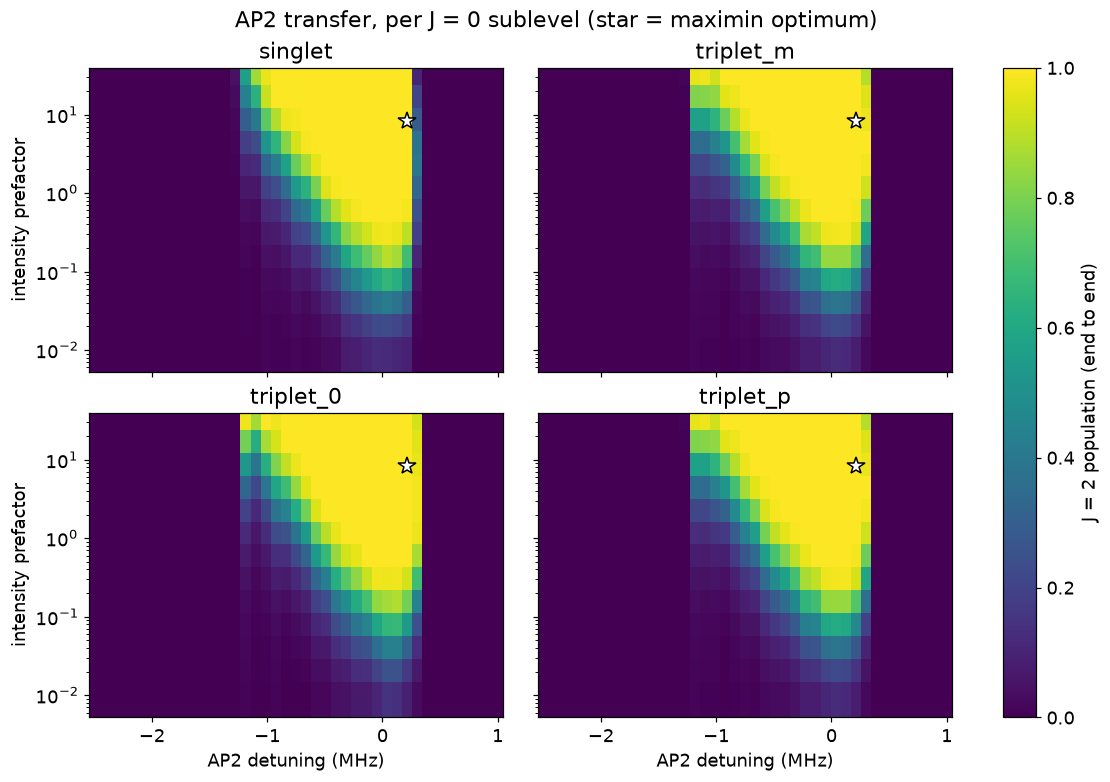

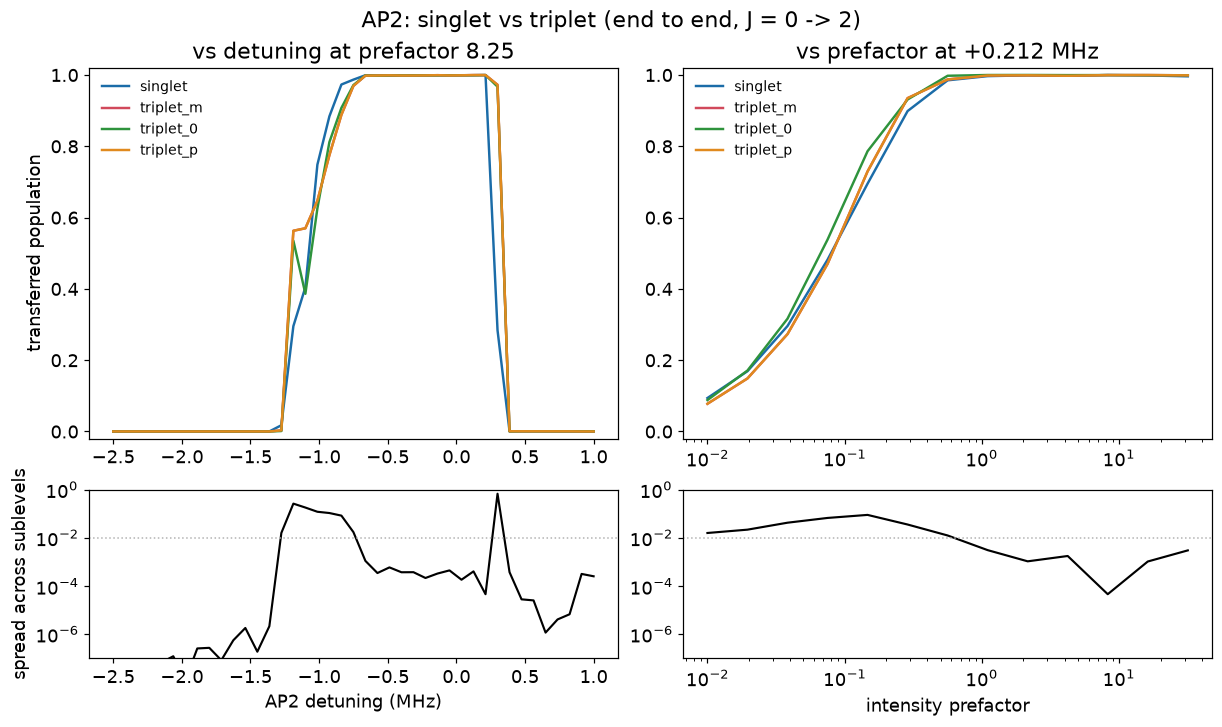

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharex=True, sharey=True,
                         constrained_layout=True)
for s, (name, ax) in enumerate(zip(STATE_NAMES, axes.ravel())):
    im = ax.pcolormesh(det2_axis / 1e6, pref_axis, ap2_matched[:, :, s].T,
                       vmin=0, vmax=1, shading="nearest", cmap="viridis")
    ax.set_yscale("log")
    ax.set_title(name)
    ax.plot(D2_OPT / 1e6, PREF2_OPT, "w*", ms=12, mec="k")
for ax in axes[-1]:
    ax.set_xlabel("AP2 detuning (MHz)")
for ax in axes[:, 0]:
    ax.set_ylabel("intensity prefactor")
fig.colorbar(im, ax=axes, label="J = 2 population (end to end)")
fig.suptitle("AP2 transfer, per J = 0 sublevel (star = maximin optimum)")
plt.show()

comparison_figure(ap2_matched, det2_axis, pref_axis, di2, pi2,
                  "AP2 detuning (MHz)", "AP2: singlet vs triplet (end to end, J = 0 -> 2)")

## Diagnostics

### Do the three observables agree?

Two different things are being checked, and it matters not to conflate them.

**matched vs tracked** is the label-swap check. `matched` identifies the target by its
quantum numbers in the final eigenbasis; `tracked` reads the same population through an
index fixed at t = 0. They agree only while the adiabatic label survived the trajectory,
so a difference means the tracked reading has followed the wrong branch through a crossing
and is the one to distrust. At the step counts used here they agree; at `N_steps = 80_000`
the J = 2 singlet target does swap (index 32 to 29), which is why this check exists rather
than being assumed away.

**manifold minus matched** is *not* an error. It is real population that reached the right
rotational manifold but a different hyperfine substate, and it is large away from the
optimum. It is reported to show where the losses go, and is deliberately not counted as
transfer.

In [18]:
for label, matched, tracked, manifold, di, pi in [
    ("AP1", ap1_matched, ap1_tracked, ap1_manifold, di1, pi1),
    ("AP2", ap2_matched, ap2_tracked, ap2_manifold, di2, pi2),
]:
    swap = np.abs(matched - tracked).max()
    leak = (manifold - matched).max()
    print(f"{label}:")
    print(f"  max |matched - tracked|  = {swap:.3e}   "
          + ("tracked index still names the right state"
             if swap < 1e-6 else "LABEL SWAP: the tracked column is wrong, matched is right"))
    print(f"  max (manifold - matched) = {leak:.3e}   "
          "reached the right J, wrong hyperfine substate")
    print(f"  ... of which, at the optimum: {(manifold - matched)[di, pi].max():.3e}")

AP1:
  max |matched - tracked|  = 0.000e+00   tracked index still names the right state
  max (manifold - matched) = 2.089e-01   reached the right J, wrong hyperfine substate
  ... of which, at the optimum: 1.026e-04
AP2:
  max |matched - tracked|  = 0.000e+00   tracked index still names the right state
  max (manifold - matched) = 8.185e-01   reached the right J, wrong hyperfine substate
  ... of which, at the optimum: 3.689e-04


### Timestep convergence

The top of the prefactor range drives the fastest Rabi oscillation and is where `N_steps`
is most likely to under-resolve. Re-running the strongest-drive column at double the step
count tests it.

In [19]:
det_c, pref_c = sp.scan_grid(
    n_fields=1, detunings_hz=det1_axis[::8], intensity_prefactors=pref_axis[-1],
)
conv = {}
for n_steps in (N_STEPS, 2 * N_STEPS):
    r = sim_ap1.run_microwave_scan(
        detunings_hz=det_c, intensity_prefactors=pref_c, N_steps=n_steps,
        store_final_probabilities=True, progress=False, workers=WORKERS,
    )
    conv[n_steps] = transfer_observables(r, targets_j1, j_target=1)[2]

delta = np.abs(conv[N_STEPS] - conv[2 * N_STEPS]).max()
print(f"max |P(N={N_STEPS}) - P(N={2 * N_STEPS})| at the strongest drive = {delta:.3e}")
print("converged" if delta < 5e-3 else "NOT converged -- raise N_STEPS")

max |P(N=10000) - P(N=20000)| at the strongest drive = 6.996e-04
converged


### Are the four sublevels really independent?

The claim that propagating all four together is identical to running them separately is
what makes the post-hoc weighting valid. Rather than assert it, run one grid point with the
singlet alone and compare.

In [20]:
sim_single = Simulator(
    setup["trajectory"], setup["electric_field"], setup["magnetic_field"],
    [initial_states[0]], hamiltonian, [mf01],
)
one_det, one_pref = sp.scan_grid(
    n_fields=1, detunings_hz=D1_OPT, intensity_prefactors=PREF1_OPT,
)
solo = sim_single.run_microwave_scan(
    detunings_hz=one_det, intensity_prefactors=one_pref, N_steps=N_STEPS,
    store_final_probabilities=True, progress=False,
)

together = res1.probabilities_final.reshape(shape1[:2] + res1.probabilities_final.shape[1:])
diff = np.abs(solo.probabilities_final[0, 0] - together[di1, pi1, 0]).max()
print(f"max |P(singlet alone) - P(singlet in the four-state run)| = {diff:.3e}")
assert diff < 1e-12, "initial states are not propagating independently"
print("independent: the four sublevels can be weighted after the fact")

max |P(singlet alone) - P(singlet in the four-state run)| = 1.776e-15
independent: the four sublevels can be weighted after the fact


## Combining with the rotational-cooling weights

Because the sublevels propagate independently and RC leaves an *incoherent* mixture,
weighting afterwards is exact. Nominally 2/3 of the population is in F = 0 and 1/3 is spread
over the three F = 1 sublevels.

(A *coherent* superposition would be a different calculation, and is not supported: the
simulator snaps each supplied state to the nearest eigenvector.)

In [21]:
WEIGHTS = np.array([2 / 3, 1 / 9, 1 / 9, 1 / 9])
assert np.isclose(WEIGHTS.sum(), 1.0)

ap1_weighted = ap1_matched @ WEIGHTS
ap2_weighted = ap2_matched @ WEIGHTS

print(f"RC-weighted AP1 transfer at the AP1 optimum:      {ap1_weighted[di1, pi1]:.6f}")
print(f"RC-weighted end-to-end J=0->2 at the AP2 optimum: {ap2_weighted[di2, pi2]:.6f}")
print(f"unweighted mean over the four sublevels:          {ap2_matched[di2, pi2].mean():.6f}")
print("\nThe weighted and unweighted numbers agree to the level of the sublevel spread, "
      "which is the point: the answer does not depend on the RC populations.")

RC-weighted AP1 transfer at the AP1 optimum:      0.999965
RC-weighted end-to-end J=0->2 at the AP2 optimum: 0.999568
unweighted mean over the four sublevels:          0.999554

The weighted and unweighted numbers agree to the level of the sublevel spread, which is the point: the answer does not depend on the RC populations.


## Summary

In [22]:
rows = [
    ("AP1  J=0 -> 1", ap1_matched[di1, pi1]),
    ("AP2  conditional", ap2_conditional[di2, pi2]),
    ("end to end  J=0 -> 2", ap2_matched[di2, pi2]),
]
header = f"{'':22}" + "".join(f"{n:>12}" for n in STATE_NAMES) + f"{'spread':>12}"
print(header)
print("-" * len(header))
for label, values in rows:
    print(f"{label:22}" + "".join(f"{v:12.6f}" for v in values)
          + f"{values.max() - values.min():12.2e}")

worst_spread = max(v.max() - v.min() for _, v in rows)
worst_value = min(v.min() for _, v in rows)
print()
print(f"Every sublevel transfers at >= {worst_value:.6f}, and the largest spread")
print(f"between the singlet and any triplet sublevel is {worst_spread:.1e}.")
print("The singlet and triplet cases are equivalent to well below any")
print("experimentally relevant level.")

print()
print(f"AP1 optimum: {D1_OPT / 1e6:+.3f} MHz, {mf01.intensity.power * PREF1_OPT:.3e} W "
      f"(prefactor {PREF1_OPT:.3f}, Rabi x {np.sqrt(PREF1_OPT):.2f})")
print(f"AP2 optimum: {D2_OPT / 1e6:+.3f} MHz, {mf12.intensity.power * PREF2_OPT:.3e} W "
      f"(prefactor {PREF2_OPT:.3f}, Rabi x {np.sqrt(PREF2_OPT):.2f})")

                           singlet   triplet_m   triplet_0   triplet_p      spread
----------------------------------------------------------------------------------
AP1  J=0 -> 1             0.999983    0.999894    0.999997    0.999894    1.02e-04
AP2  conditional          0.999596    0.999638    0.999572    0.999643    7.12e-05
end to end  J=0 -> 2      0.999579    0.999532    0.999568    0.999538    4.63e-05

Every sublevel transfers at >= 0.999532, and the largest spread
between the singlet and any triplet sublevel is 1.0e-04.
The singlet and triplet cases are equivalent to well below any
experimentally relevant level.

AP1 optimum: +1.350 MHz, 6.462e-04 W (prefactor 16.156, Rabi x 4.02)
AP2 optimum: +0.212 MHz, 4.127e-04 W (prefactor 8.254, Rabi x 2.87)


## Microwave power at the optimum

The scans vary a dimensionless **intensity prefactor** relative to each rung's nominal
power, so the optimum has to be converted back to Watts to be usable. Prefactor is an
intensity ratio, so the Rabi rate scales as its square root.

These are total beam powers for the modelled optics -- a Gaussian with a 1 inch FWHM, pure
z polarization, k along x. Translating them to the experiment assumes the same geometry;
what actually sets the transfer is the Rabi rate, which is the geometry-independent number
in the last column.

In [23]:
def to_dbm(power_w):
    return 10 * np.log10(power_w * 1e3)


def power_report(field, lower, upper, r0, pref_opt, pref_axis, worst, label, threshold=0.999):
    nominal = field.intensity.power
    opt_w = nominal * pref_opt
    rabi = field.calculate_rabi_rate(lower, upper, opt_w, r0)
    print(f"{label}:")
    print(f"  nominal power    {nominal:.4e} W  ({to_dbm(nominal):+7.2f} dBm)   prefactor 1")
    print(f"  optimum power    {opt_w:.4e} W  ({to_dbm(opt_w):+7.2f} dBm)   "
          f"prefactor {pref_opt:.3f}")
    print(f"  Rabi rate there  {rabi / 2 / np.pi / 1e3:.1f} kHz")

    ok = (worst > threshold).any(axis=0)
    if ok.any():
        lo, hi = nominal * pref_axis[ok].min(), nominal * pref_axis[ok].max()
        r_lo = field.calculate_rabi_rate(lower, upper, lo, r0) / 2 / np.pi / 1e3
        r_hi = field.calculate_rabi_rate(lower, upper, hi, r0) / 2 / np.pi / 1e3
        print(f"  all four sublevels > {threshold} for "
              f"{lo:.3e} to {hi:.3e} W  ({to_dbm(lo):+.2f} to {to_dbm(hi):+.2f} dBm), "
              f"Rabi {r_lo:.0f} to {r_hi:.0f} kHz")


power_report(mf01, initial_states[2], targets_j1[2], r0_01, PREF1_OPT, pref_axis,
             ap1_matched.min(axis=-1), "AP1  J=0 -> 1")
print()
power_report(mf12, targets_j1[2], targets_j2[2], r0_12, PREF2_OPT, pref_axis,
             ap2_matched.min(axis=-1), "AP2  J=1 -> 2  (AP1 held at its optimum)")

AP1  J=0 -> 1:
  nominal power    4.0000e-05 W  ( -13.98 dBm)   prefactor 1
  optimum power    6.4624e-04 W  (  -1.90 dBm)   prefactor 16.156
  Rabi rate there  158.6 kHz
  all four sublevels > 0.999 for 1.687e-04 to 1.265e-03 W  (-7.73 to +1.02 dBm), Rabi 81 to 222 kHz

AP2  J=1 -> 2  (AP1 held at its optimum):
  nominal power    5.0000e-05 W  ( -13.01 dBm)   prefactor 1
  optimum power    4.1270e-04 W  (  -3.84 dBm)   prefactor 8.254
  Rabi rate there  113.3 kHz
  all four sublevels > 0.999 for 1.077e-04 to 8.078e-04 W  (-9.68 to -0.93 dBm), Rabi 58 to 159 kHz


In [24]:
import polars as pl

def scan_frame(det_axis, pref_axis, transfer, stage):
    d, p = np.meshgrid(det_axis, pref_axis, indexing="ij")
    data = {"stage": np.full(d.size, stage), "detuning_hz": d.ravel(),
            "intensity_prefactor": p.ravel()}
    for s, name in enumerate(STATE_NAMES):
        data[name] = transfer[:, :, s].ravel()
    return pl.DataFrame(data)

frame = pl.concat([
    scan_frame(det1_axis, pref_axis, ap1_matched, "AP1"),
    scan_frame(det2_axis, pref_axis, ap2_matched, "AP2_end_to_end"),
])

out = Path("results") / "SPA_singlet_vs_triplet_no_background.csv"
out.parent.mkdir(exist_ok=True)
frame.write_csv(out)
print(f"wrote {out}  ({frame.height} rows)")
print("Note: generated CSVs are not committed unless explicitly wanted.")
frame.head()

wrote results\SPA_singlet_vs_triplet_no_background.csv  (1066 rows)


Note: generated CSVs are not committed unless explicitly wanted.


stage,detuning_hz,intensity_prefactor,singlet,triplet_m,triplet_0,triplet_p
str,f64,f64,f64,f64,f64,f64
"""AP1""",-6e6,0.01,1.5958e-7,7.3541e-8,7.7478e-8,7.3539e-8
"""AP1""",-6e6,0.019573,1.5017e-7,6.3388e-8,8.4966e-8,6.3387e-8
"""AP1""",-6e6,0.038312,1.3657e-7,4.9909e-8,9.8290e-8,4.9908e-8
"""AP1""",-6e6,0.074989,1.1712e-7,3.2952e-8,1.2261e-7,3.2951e-8
"""AP1""",-6e6,0.14678,9.0233e-8,1.4190e-8,1.6782e-7,1.4190e-8


## Scope and caveats

- **Single forward velocity** (184 m/s). Velocity averaging is out of scope here; the
  pattern for it is in `SPA2 for paper.ipynb` (loop over velocities, Gaussian weights with
  sigma_v = 16 m/s).
- **No stray microwaves.** Adding the SPA or RC background fields changes the picture and
  is what `SPA2 - parameter scans with SPA and RC background.ipynb` and
  `scripts/analyze_spa2_bg_feature.py` cover.
- **The AP1 optimum is chosen on a grid**, so it is only as good as the grid spacing.
- The **transfer numbers reported are the matched partner** for each chain, identified by
  its quantum numbers in the final eigenbasis, not a sum over anything. The tracked-index
  and manifold readings appear only in the diagnostics cell, as a label-swap check and as
  an indication of where losses go.
- **Adiabatic labels are not reliable in this system**, which is why the reported number
  does not use one. The Stark ramp-down folds the hyperfine structure together and most
  eigenstate labels cross something on the way out; `result.unreliable_labels()` reports
  which. At the step counts used here no target is affected, but that is verified rather
  than assumed -- the J = 2 singlet does swap at `N_steps = 80_000`.
- The **optimum is a grid argmax**, and many grid points saturate near 1, so the exact
  optimum coordinates are somewhat arbitrary. The reported operating window -- the region
  where all four sublevels clear the threshold -- is the more meaningful output.